In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Preliminary: Data Loading

In [2]:
train_set = pd.read_csv('../HW1_WET/prepared_data/prepared_train_data.csv')
test_set = pd.read_csv('../HW1_WET/prepared_data/prepared_test_data.csv')

# Part1: Basic model selection with k-Nearest Neighbors

* Question 1

In [3]:
from sklearn.neighbors import KNeighborsClassifier
# Extracting PCR_04 and PCR_09
X_train_pcr49, y_train_pcr49 = train_set[["PCR_04","PCR_09"]], train_set["spread"]
X_test_pcr49,y_test_pcr49 = test_set[["PCR_04","PCR_09"]], test_set["spread"]

In [4]:
clf = KNeighborsClassifier(n_neighbors=1) # model instance
clf.fit(X= X_train_pcr49, y= y_train_pcr49) # fitting the model

KNeighborsClassifier(n_neighbors=1)

C:\Users\kingh\Desktop\Semester6\Intro-to-machine-learning\Intro-toMachine-Learning-Technion\env\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


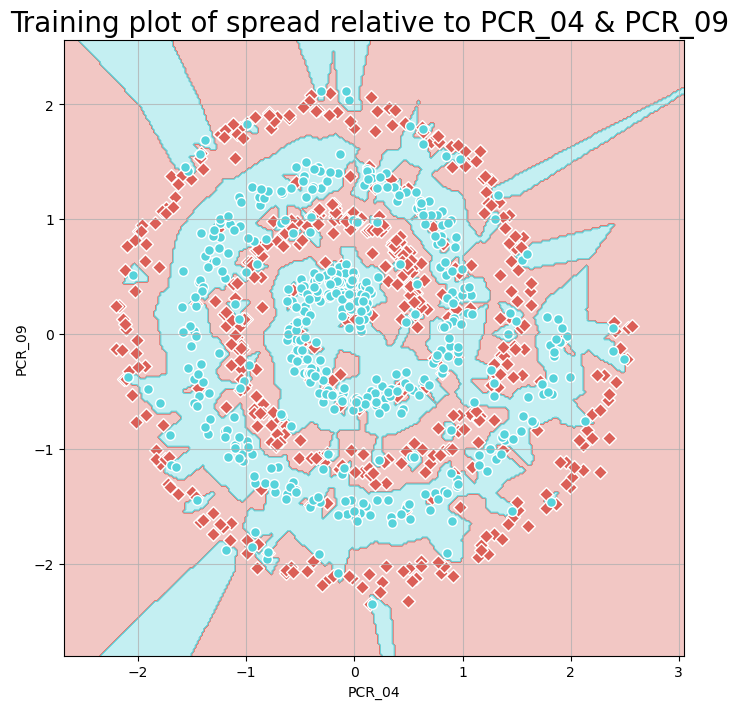

In [5]:
from visualize_clf import visualize_clf
# plotting
visualize_clf(clf = clf,
              X = X_train_pcr49,
              Y = y_train_pcr49,
              title ="Training plot of spread relative to PCR_04 & PCR_09 ",
              xlabel = "PCR_04",
              ylabel ="PCR_09")

* Question 2

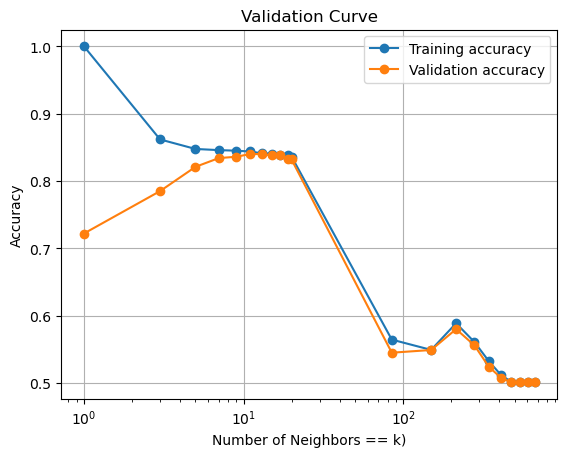

In [6]:
from sklearn.model_selection import cross_validate
k_grid = list(range(1, 20, 2)) + list(range(20, 695, 65))

# Initialize lists to hold mean train and validation scores
train_scores = []
validation_scores = []

# Perform cross-validation for each k
for k in k_grid:
    # Model instance
    clf = KNeighborsClassifier(n_neighbors=k)
    cv_results = cross_validate(estimator=clf, X=X_train_pcr49, y=y_train_pcr49, cv=8, n_jobs=None,
                                return_train_score=True, scoring='accuracy')
    
    train_scores.append(np.mean(cv_results['train_score']))
    validation_scores.append(np.mean(cv_results['test_score']))

# Validation curv
plt.semilogx(k_grid, train_scores, label='Training accuracy', marker='o')
plt.semilogx(k_grid, validation_scores, label='Validation accuracy', marker='o')
plt.xlabel('Number of Neighbors == k)')
plt.ylabel('Accuracy')
plt.title('Validation Curve')
plt.legend()
plt.grid()
plt.show()


In [7]:
max_validation_k = k_grid[validation_scores.index(max(validation_scores))]
max_validation_k

11

### Result : K == 11 is the best with cross validation with accuracy 84%

In [8]:
# Print the results for each k
for k, train_score, validation_score in zip(k_grid, train_scores, validation_scores):
    if k == max_validation_k:
        print(f"k: {k}, Training Accuracy: {train_score:.4f}, Validation Accuracy: {validation_score:.4f} <-- highest validation accuracy")
    else:
        print(f"k: {k}, Training Accuracy: {train_score:.4f}, Validation Accuracy: {validation_score:.4f}")

print(f"\nThe value of k with the highest validation accuracy is: {max_validation_k}")

k: 1, Training Accuracy: 1.0000, Validation Accuracy: 0.7220
k: 3, Training Accuracy: 0.8617, Validation Accuracy: 0.7850
k: 5, Training Accuracy: 0.8476, Validation Accuracy: 0.8210
k: 7, Training Accuracy: 0.8459, Validation Accuracy: 0.8340
k: 9, Training Accuracy: 0.8450, Validation Accuracy: 0.8360
k: 11, Training Accuracy: 0.8439, Validation Accuracy: 0.8400 <-- highest validation accuracy
k: 13, Training Accuracy: 0.8411, Validation Accuracy: 0.8400
k: 15, Training Accuracy: 0.8407, Validation Accuracy: 0.8380
k: 17, Training Accuracy: 0.8393, Validation Accuracy: 0.8380
k: 19, Training Accuracy: 0.8381, Validation Accuracy: 0.8330
k: 20, Training Accuracy: 0.8363, Validation Accuracy: 0.8320
k: 85, Training Accuracy: 0.5644, Validation Accuracy: 0.5450
k: 150, Training Accuracy: 0.5491, Validation Accuracy: 0.5490
k: 215, Training Accuracy: 0.5887, Validation Accuracy: 0.5800
k: 280, Training Accuracy: 0.5609, Validation Accuracy: 0.5560
k: 345, Training Accuracy: 0.5323, Valid

* Question 3

In [9]:
optimal_k = max_validation_k
clf = KNeighborsClassifier(n_neighbors=optimal_k) # model instance
clf.fit(X= X_train_pcr49, y= y_train_pcr49) # fitting the model

KNeighborsClassifier(n_neighbors=11)

C:\Users\kingh\Desktop\Semester6\Intro-to-machine-learning\Intro-toMachine-Learning-Technion\env\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


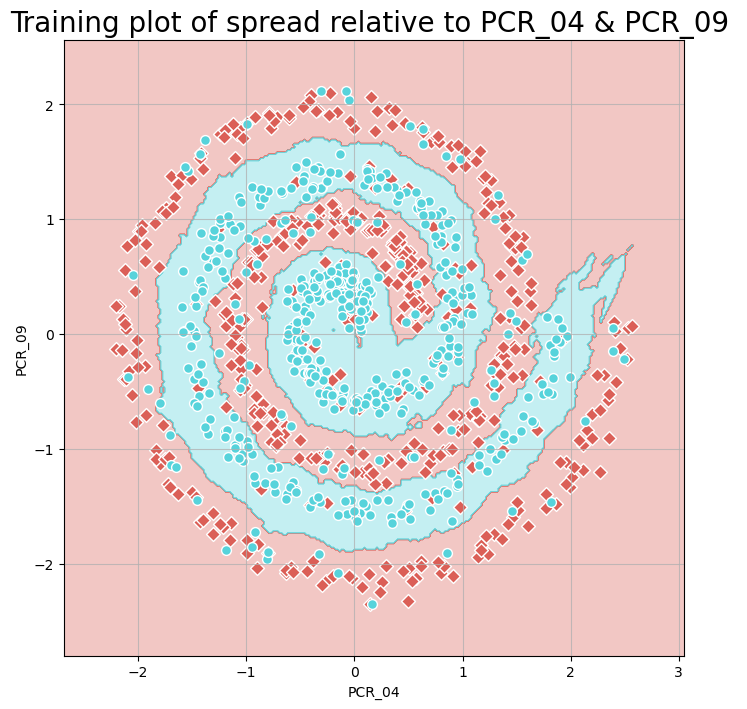

In [10]:
# plotting
visualize_clf(clf = clf,
              X = X_train_pcr49,
              Y = y_train_pcr49,
              title ="Training plot of spread relative to PCR_04 & PCR_09 ",
              xlabel = "PCR_04",
              ylabel ="PCR_09")

In [11]:
train_score ,test_score= clf.score(X = X_train_pcr49,y = y_train_pcr49),clf.score(X = X_test_pcr49,y = y_test_pcr49)
train_score ,test_score

(0.845, 0.828)

# Part 2: Decision trees

* Question 5

In [12]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
# Extracting PCR_03 and PCR_10 and blood_group== Special Property
X_train_pcr310, y_train_pcr310 = train_set[["PCR_03","PCR_10","SpecialProperty"]], train_set["risk"]
X_test_pcr310,y_test_pcr310 = test_set[["PCR_03","PCR_10","SpecialProperty"]], test_set["risk"]

In [13]:
clf_tree = DecisionTreeClassifier(criterion="entropy",max_depth=3,random_state=42)
clf_tree.fit(X = X_train_pcr310,y = y_train_pcr310)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

[Text(0.5769230769230769, 0.875, 'PCR_10 <= 0.759\nentropy = 0.994\nsamples = 1000\nvalue = [547, 453]\nclass = -1'),
 Text(0.3076923076923077, 0.625, 'PCR_03 <= -0.773\nentropy = 0.999\nsamples = 929\nvalue = [479, 450]\nclass = -1'),
 Text(0.15384615384615385, 0.375, 'PCR_10 <= -0.559\nentropy = 0.572\nsamples = 96\nvalue = [83, 13]\nclass = -1'),
 Text(0.07692307692307693, 0.125, 'entropy = 0.0\nsamples = 23\nvalue = [23, 0]\nclass = -1'),
 Text(0.23076923076923078, 0.125, 'entropy = 0.676\nsamples = 73\nvalue = [60, 13]\nclass = -1'),
 Text(0.46153846153846156, 0.375, 'PCR_03 <= 0.492\nentropy = 0.998\nsamples = 833\nvalue = [396, 437]\nclass = +1'),
 Text(0.38461538461538464, 0.125, 'entropy = 0.958\nsamples = 594\nvalue = [226, 368]\nclass = +1'),
 Text(0.5384615384615384, 0.125, 'entropy = 0.867\nsamples = 239\nvalue = [170, 69]\nclass = -1'),
 Text(0.8461538461538461, 0.625, 'PCR_10 <= 0.83\nentropy = 0.253\nsamples = 71\nvalue = [68, 3]\nclass = -1'),
 Text(0.7692307692307693,

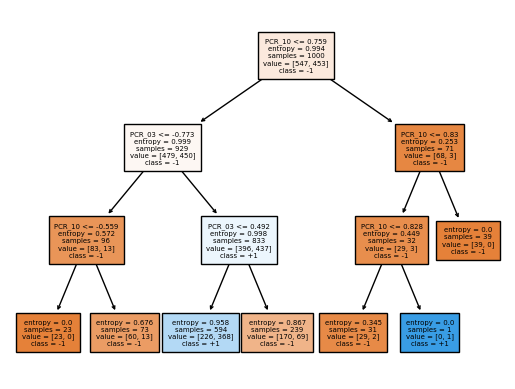

In [14]:
plot_tree(decision_tree=clf_tree,
          filled = True,
          fontsize=5,
          class_names=["-1","+1"], # Risk values
          feature_names=["PCR_03","PCR_10","SpecialProperty"])

In [15]:
clf_tree.score(X = X_train_pcr310,y = y_train_pcr310)

0.69

* Question 6

In [16]:
from seaborn import heatmap

grid = {"max_depth": np.arange(5, 30, 1),
       "min_samples_leaf": np.arange(1, 15, 2)}


In [17]:
from sklearn.model_selection import GridSearchCV
clf = DecisionTreeClassifier(criterion="entropy",random_state=42)
# GridSearchCV
gs_clf = GridSearchCV(estimator=clf,
                      param_grid=grid,
                      cv=5,
                      verbose=1,
                      scoring='accuracy'  # Ensure we are scoring by accuracy
                     )

# fit the grid search CV version of clf
gs_clf.fit(X = X_train_pcr310,y = y_train_pcr310)

Fitting 5 folds for each of 175 candidates, totalling 875 fits


GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(criterion='entropy',
                                              random_state=42),
             param_grid={'max_depth': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
       22, 23, 24, 25, 26, 27, 28, 29]),
                         'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13])},
             scoring='accuracy', verbose=1)

In [18]:
gs_clf.best_params_,gs_clf.best_score_

({'max_depth': 11, 'min_samples_leaf': 9}, 0.8310000000000001)

In [19]:
gs_clf.score(X_test_pcr310,y_test_pcr310)

0.82

- Making heatmap

### Mean Validation Accuracy

Fitting 5 folds for each of 175 candidates, totalling 875 fits


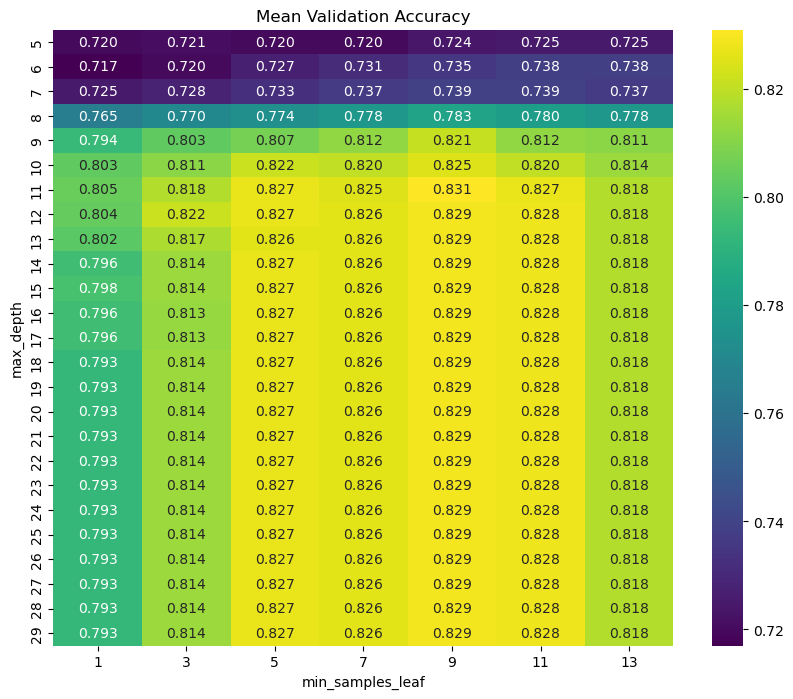

In [20]:
# fit the grid search CV version of clf
gs_clf.fit(X = X_train_pcr310,y = y_train_pcr310)

# Get results into a DataFrame
results = pd.DataFrame(gs_clf.cv_results_)

# Reshape results to get a matrix suitable for a heatmap
heatmap_data = results.pivot(index='param_max_depth', columns='param_min_samples_leaf', values='mean_test_score')

# Draw the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap='viridis')
plt.title('Mean Validation Accuracy')
plt.xlabel('min_samples_leaf')
plt.ylabel('max_depth')
plt.show()


### Mean Training  Accuracy

Fitting 5 folds for each of 175 candidates, totalling 875 fits


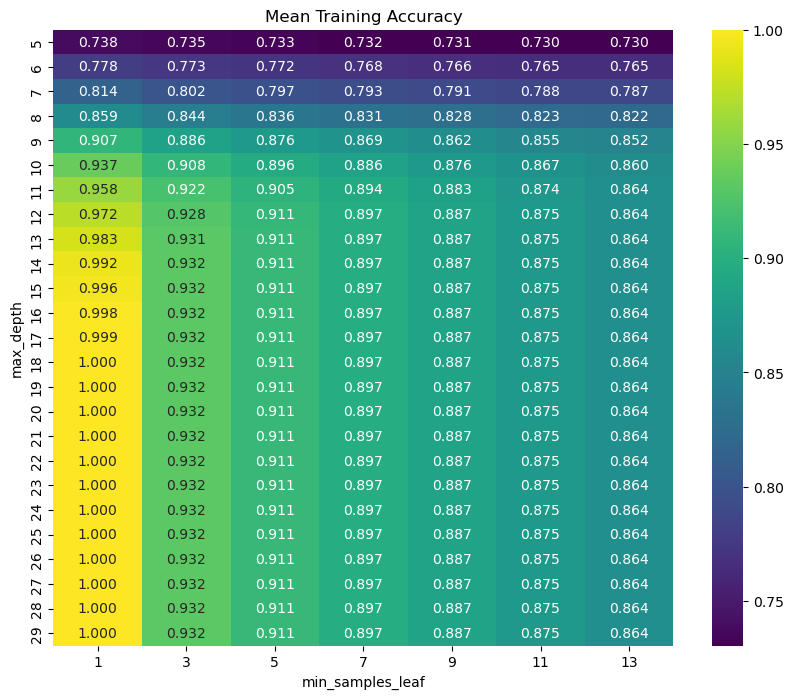

In [21]:
clf = DecisionTreeClassifier(criterion="entropy",random_state=42)
# GridSearchCV
gs_clf = GridSearchCV(estimator=clf,
                      param_grid=grid,
                      cv=5,
                      verbose=1,
                      scoring='accuracy',  # Ensure we are scoring by accuracy
                      return_train_score= True
                     )

# fit the grid search CV version of clf
gs_clf.fit(X = X_train_pcr310,y = y_train_pcr310)

# Get results into a DataFrame
results = pd.DataFrame(gs_clf.cv_results_)

# Reshape results to get a matrix suitable for a heatmap
heatmap_data = results.pivot(index='param_max_depth', columns='param_min_samples_leaf', values='mean_train_score')

# Draw the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap='viridis')
plt.title('Mean Training Accuracy')
plt.xlabel('min_samples_leaf')
plt.ylabel('max_depth')
plt.show()


In [22]:
gs_clf.best_params_,gs_clf.best_score_

({'max_depth': 11, 'min_samples_leaf': 9}, 0.8310000000000001)

* Question 8

In [23]:
clf = DecisionTreeClassifier(max_depth=11,
                             min_samples_leaf=9,
                             criterion="entropy",
                             random_state=42)
clf.fit(X = X_train_pcr310,y = y_train_pcr310)
clf.score(X = X_train_pcr310,y = y_train_pcr310),clf.score(X = X_test_pcr310,y = y_test_pcr310)

(0.891, 0.82)

# Part 3 Linear SVM and the Polynomial kernel

In [24]:
# Extracting PCR_04 and PCR_09
X_train_pcr49, y_train_pcr49 = train_set[["PCR_04","PCR_09"]], train_set["spread"]
X_test_pcr49,y_test_pcr49 = test_set[["PCR_04","PCR_09"]], test_set["spread"]

* SoftSVM module

In [25]:
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class SoftSVM(BaseEstimator, ClassifierMixin):
    """
    Custom C-Support Vector Classification.
    """
    def __init__(self, C: float, lr: float = 1e-5, batch_size = 32):
        """
        Initialize an instance of this class.
        ** Do not edit this method **

        :param C: inverse strength of regularization. Must be strictly positive.
        :param lr: the SGD learning rate (step size)
        """
        self.C = C
        self.lr = lr
        self.batch_size = batch_size
        self.w = None
        self.b = 0.0

    # Initialize a random weight vector
    def init_solution(self, n_features: int):
        """
        Randomize an initial solution (weight vector)
        ** Do not edit this method **

        :param n_features:
        """
        self.w = np.random.randn(n_features)
        self.b = 0.0

    @staticmethod
    def loss(w, b: float, C: float, X, y):
        """
        Compute the SVM objective loss.

        :param w: weight vector for linear classification; array of shape (n_features,)
        :param b: bias scalar for linear classification
        :param C: inverse strength of regularization. Must be strictly positive.
        :param X: samples for loss computation; array of shape (n_samples, n_features)
        :param y: targets for loss computation; array of shape (n_samples,)
        :return: the Soft SVM objective loss (float scalar)
        """
        margins = (X.dot(w) + b)
        hinge_inputs = np.multiply(margins, y)

        norm = np.linalg.norm(w)

        # TODO: complete the loss calculation [DONE]
    
        hinge_values = np.maximum(0, 1 - hinge_inputs)
        ret_loss = norm**2 + C * np.sum(hinge_values)

        return ret_loss

    @staticmethod
    def subgradient(w, b: float, C: float, X, y):
        """
        Compute the (analytical) SVM objective sub-gradient.
    
        :param w: weight vector for linear classification; array of shape (n_features,)
        :param b: bias scalar for linear classification
        :param C: inverse strength of regularization. Must be strictly positive.
        :param X: samples for loss computation; array of shape (n_samples, n_features)
        :param y: targets for loss computation; array of shape (n_samples,)
        :return: a tuple with (the gradient of the weights, the gradient of the bias)
        """
        # make sure X and y are numpy arrays
        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()
        if isinstance(y, pd.Series):
            y = y.to_numpy()
    
        margins = X.dot(w) + b
        hinge_inputs = np.multiply(margins, y)
        f_outputs = np.where(hinge_inputs < 1, -1, 0)
        b_to_sum = np.multiply(y, f_outputs)
        w_to_sum = np.multiply(b_to_sum[:, np.newaxis], X)  # making sure correct dimensions for multiply
        g_w = 2 * w + C * np.sum(w_to_sum, axis=0)  # Summing over the samples
        g_b = C * np.sum(b_to_sum)
    
        return g_w, g_b

    def fit_with_logs(self, X, y, max_iter: int = 2000, keep_losses: bool = True):
        """
        Fit the model according to the given training data.

        :param X: training samples; array of shape (n_samples, n_features)
        :param y: training targets (+1 and -1); array of shape (n_samples,)
        :param max_iter: number of SGD iterations
        :param keep_losses:
        :return: the training losses and accuracies during training
        """
        # Initialize learned parameters
        self.init_solution(X.shape[1])

        losses = []
        accuracies = []

        if keep_losses:
            losses.append(self.loss(self.w, self.b, self.C, X, y))
            accuracies.append(self.score(X, y))

        permutation = np.random.permutation(len(y))
        X = X[permutation, :]
        y = y[permutation]
        
        # Iterate over batches
        for iter in range(0, max_iter):
            start_idx = (iter * self.batch_size) % X.shape[0]
            end_idx = min(X.shape[0], start_idx + self.batch_size)
            batch_X = X[start_idx:end_idx, :]
            batch_y = y[start_idx:end_idx]

            # TODO: Compute the (sub)gradient of the current *batch*
            g_w, g_b = self.subgradient(w=self.w, b=self.b, C=self.C, X=batch_X, y=batch_y)
            # Perform a (sub)gradient step
            # TODO: update the learned parameters correctly
            self.w -= self.lr * g_w
            self.b -= self.lr * g_b
            
            if keep_losses:
                losses.append(self.loss(self.w, self.b, self.C, X, y))
                accuracies.append(self.score(X, y))

        return losses, accuracies

    def fit(self, X, y, max_iter: int = 2000):
        """
        Fit the model according to the given training data.
        ** Do not edit this method **

        :param X: training samples; array of shape (n_samples, n_features)
        :param y: training targets (+1 and -1); array of shape (n_samples,)
        :param max_iter: number of SGD iterations
        """
        self.fit_with_logs(X, y, max_iter=max_iter, keep_losses=False)

        return self

    def predict(self, X):
        """
        Perform classification on samples in X.

        :param X: samples for prediction; array of shape (n_samples, n_features)
        :return: Predicted class labels for samples in X; array of shape (n_samples,)
                 NOTE: the labels must be either +1 or -1
        """
        # TODO: compute the predicted labels (+1 or -1)
        y_pred = np.sign(X.dot(self.w) + self.b)

        return y_pred


### Subgradients

* Question

In [26]:
def numerical_subgradient(w, b, C, X, y, delta=1e-4):
    w_ = w.copy()
    g_w = np.zeros_like(w_)
    orig_objective = SoftSVM.loss(w_, b, C, X, y)
    for i in range(g_w.shape[0]):
        w_[i] += delta
        perturbed_objective = SoftSVM.loss(w_, b, C, X, y)
        w_[i] -= delta
        g_w[i] = (perturbed_objective - orig_objective) / delta

    g_b = (SoftSVM.loss(w_, b + delta, C, X, y) - orig_objective) / delta
    return g_w, g_b



def compare_gradients(X, y, deltas, C=1, REPEATS=100, figsize=(10, 6)):
    residual_means = []

    for delta in deltas:
        residuals = []

        for _ in range(REPEATS):
            # Randomize vectors in which the gradient is computed
            w = np.random.randn(X.shape[1])
            b = np.random.randn(1)

            # Compute the two types of gradients
            analytic_grad = SoftSVM.subgradient(w, b, C, X, y)[0]
            numeric_grad = numerical_subgradient(w, b, C, X, y, delta=delta)[0]

            residual = np.linalg.norm(numeric_grad - analytic_grad)
            residuals.append(residual)

        residual_means.append(np.mean(residuals))

    plt.figure(figsize=figsize)
    plt.title('Residuals of analytical and numerical gradients', fontsize=22)
    plt.plot(deltas, residual_means, linewidth=3)      
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('$\delta$', fontsize=18)
    plt.ylabel(r'$\left\Vert \nabla_{w}p_{C}\left(w,b\right) - u_{\delta} \left(w,b\right)\right\Vert$', fontsize=18)

    plt.grid(alpha=0.5)
    plt.show()


<>:41: SyntaxWarning: invalid escape sequence '\d'
<>:41: SyntaxWarning: invalid escape sequence '\d'
C:\Users\kingh\AppData\Local\Temp\ipykernel_32868\2696906511.py:41: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('$\delta$', fontsize=18)


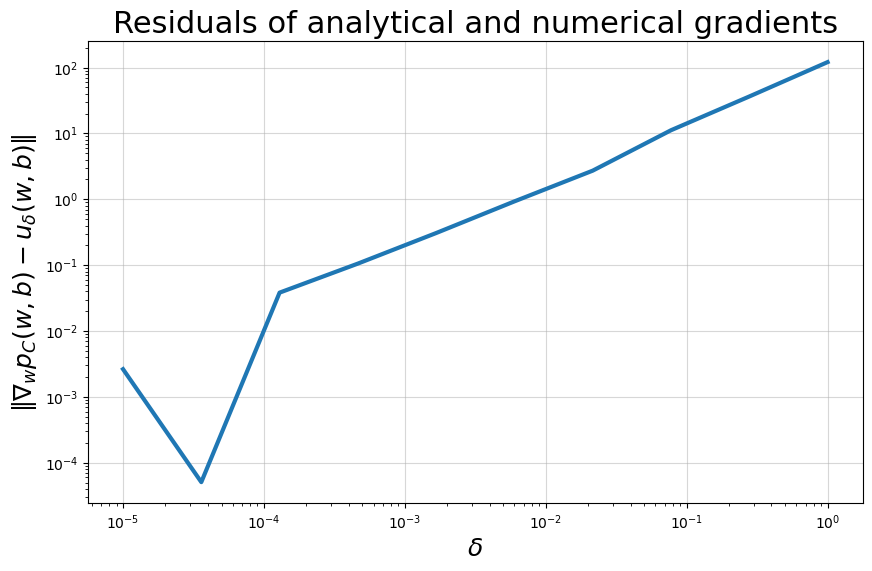

In [27]:
X_train = X_train_pcr49
y_train = y_train_pcr49
compare_gradients(X_train, y_train, deltas=np.logspace(-5, 0, 10))

* Task for Question 11

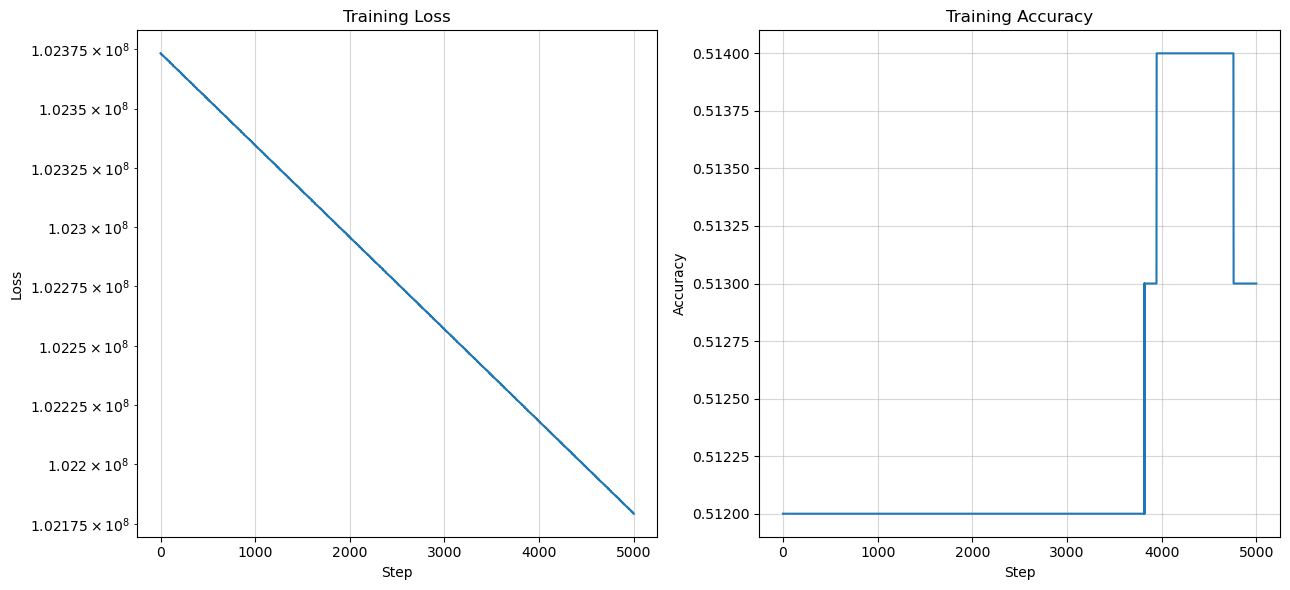

learning rate is:1e-11
last loss: 102179237.41776888, last accuracy: 0.513


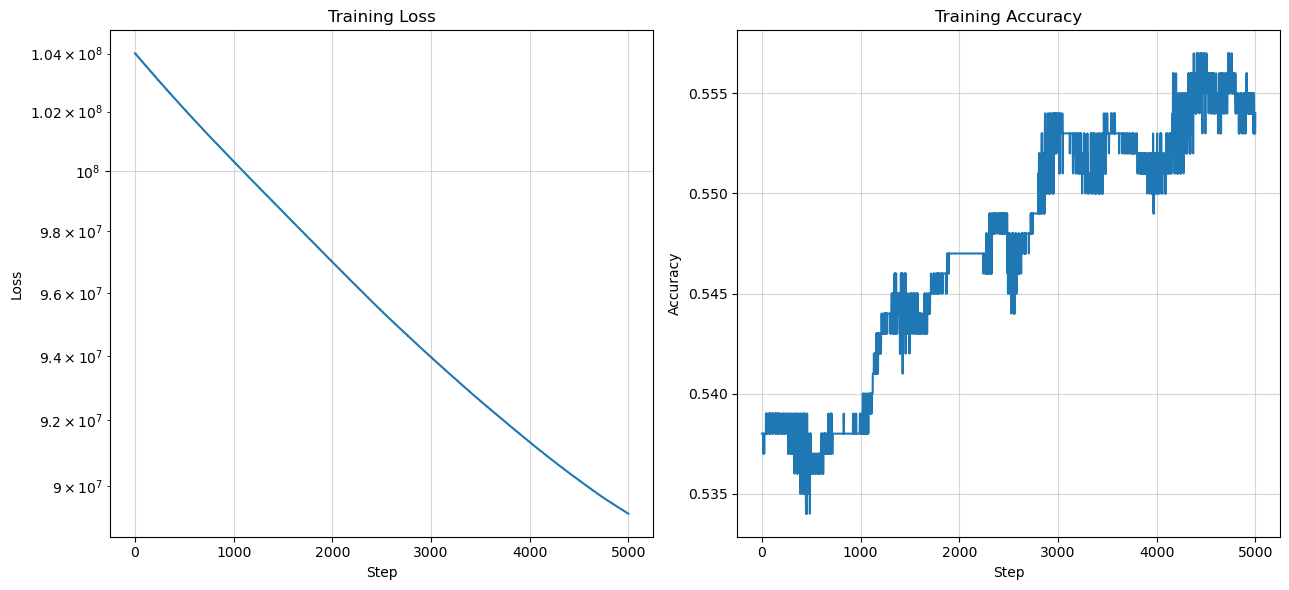

learning rate is:1e-09
last loss: 89165036.25083493, last accuracy: 0.554


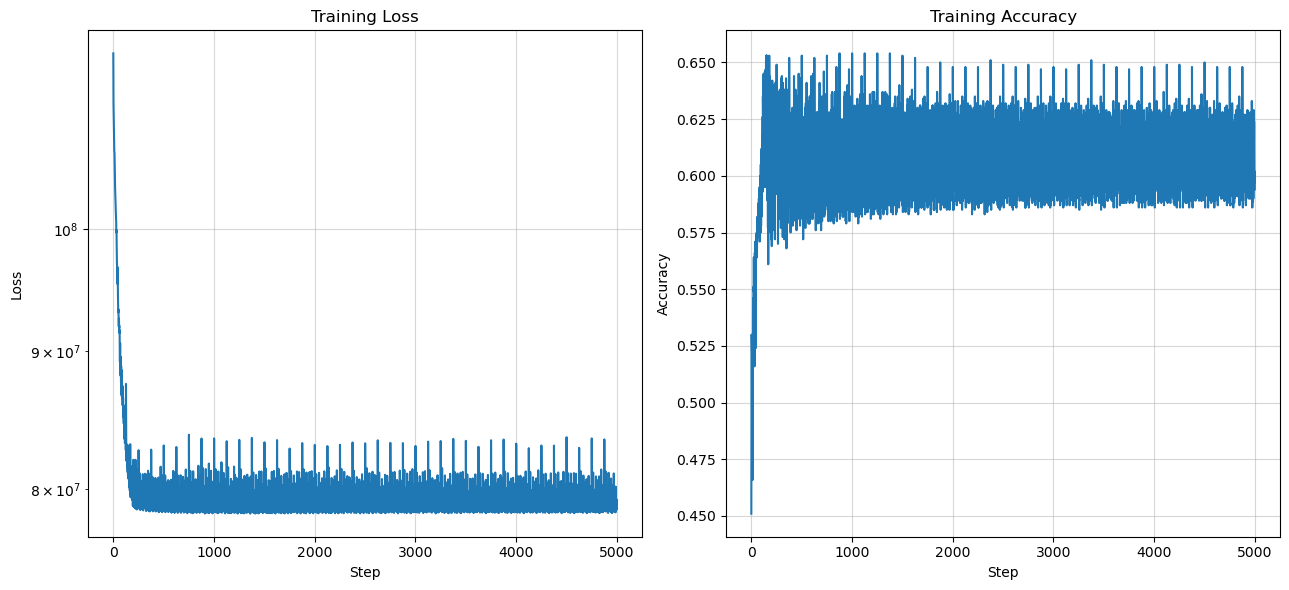

learning rate is:1e-07
last loss: 78975060.0657455, last accuracy: 0.594


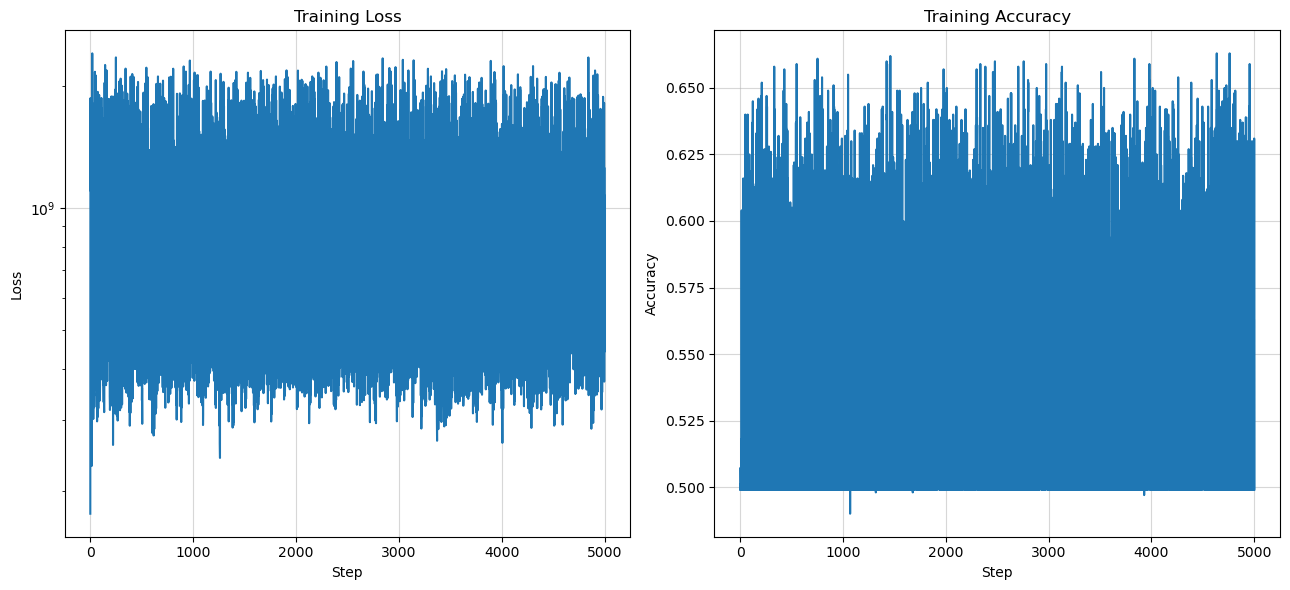

learning rate is:1e-05
last loss: 1249574030.4938805, last accuracy: 0.499


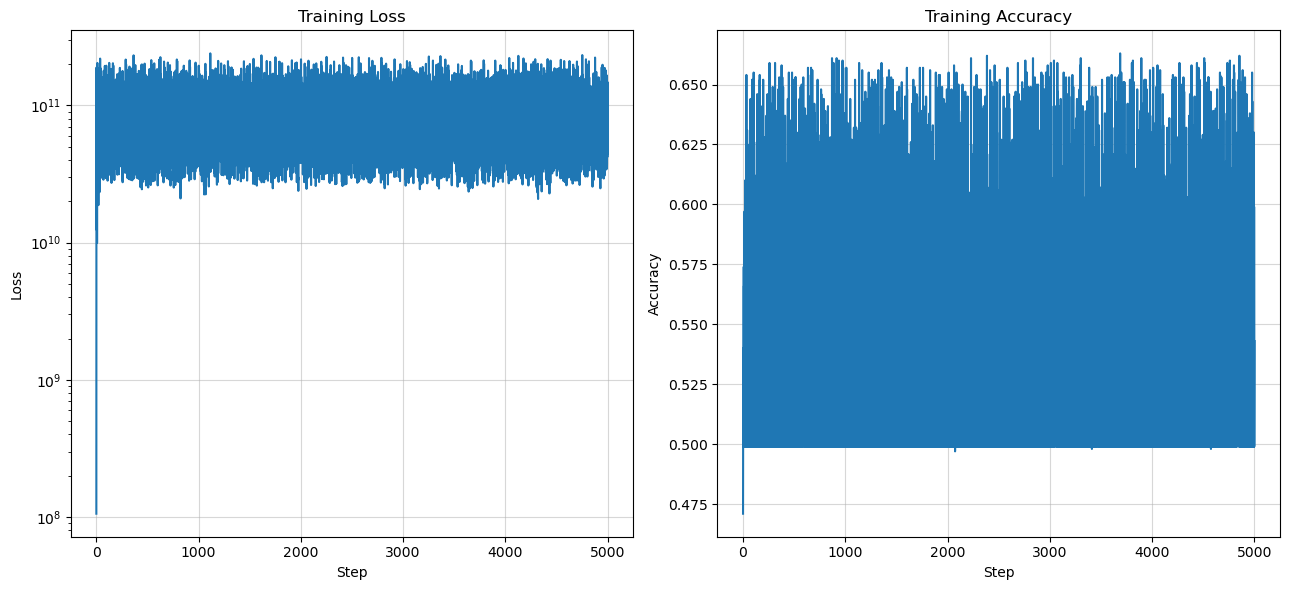

learning rate is:0.001
last loss: 42645960168.09895, last accuracy: 0.543


In [28]:
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler

C=1e5
lr_range = np.logspace(-11, -3, 5)
for lr in lr_range:
    clf = SoftSVM(C=C, lr=lr)
    X_train_poly = PolynomialFeatures(degree=3,).fit_transform(X_train)
    X_train_poly = MinMaxScaler(feature_range=(-1,1)).fit_transform(X_train_poly)
    losses, accuracies = clf.fit_with_logs(X_train_poly, y_train, max_iter=5000)
    plt.figure(figsize=(13, 6))
    plt.subplot(121), plt.grid(alpha=0.5), plt.title ("Training Loss")
    plt.semilogy(losses), plt.xlabel("Step"), plt.ylabel("Loss")
    plt.subplot(122), plt.grid(alpha=0.5), plt.title ("Training Accuracy")
    plt.plot(accuracies), plt.xlabel("Step"), plt.ylabel("Accuracy")
    plt.tight_layout()
    plt.show()
    print(f"learning rate is:{lr}")
    print(f"last loss: {losses[-1]}, last accuracy: {accuracies[-1]}")

* Task for Question 12

In [29]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
lr = 1e-9
mapping_poly = PolynomialFeatures(degree=3)
svm_clf = Pipeline([('feature_mapping', mapping_poly),
('scaler', MinMaxScaler()),
('SVM', SoftSVM(C=1e5, lr=lr))])
svm_clf.fit(X_train, y_train)

Pipeline(steps=[('feature_mapping', PolynomialFeatures(degree=3)),
                ('scaler', MinMaxScaler()),
                ('SVM', SoftSVM(C=100000.0, lr=1e-09))])

* Visualization

C:\Users\kingh\Desktop\Semester6\Intro-to-machine-learning\Intro-toMachine-Learning-Technion\env\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


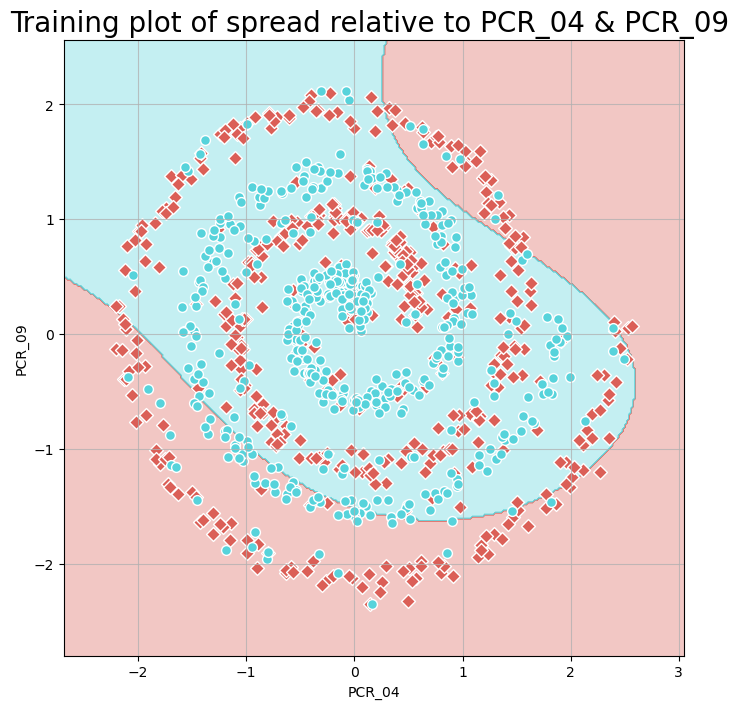

In [30]:
visualize_clf(clf = svm_clf,
              X = X_train_pcr49,
              Y = y_train_pcr49,
              title ="Training plot of spread relative to PCR_04 & PCR_09 ",
              xlabel = "PCR_04",
              ylabel ="PCR_09")

In [31]:
train_acc,test_acc = svm_clf.score(X = X_train_pcr49,y = y_train_pcr49),svm_clf.score(X = X_test_pcr49,y = y_test_pcr49)
print(f"Training Accuracy: {train_acc}, Testing Accuracy: {test_acc}")

Training Accuracy: 0.556, Testing Accuracy: 0.584


# Part 4: The RBF kernel

* Question 14

In [32]:
from sklearn.svm import SVC
# Hyper Params
C = 1
gamma = 1e-7
# Train the SVM model
rbf_model = SVC(C=C, kernel='rbf', gamma=gamma)
rbf_model.fit(X_train_pcr49, y_train_pcr49)

SVC(C=1, gamma=1e-07)

C:\Users\kingh\Desktop\Semester6\Intro-to-machine-learning\Intro-toMachine-Learning-Technion\env\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


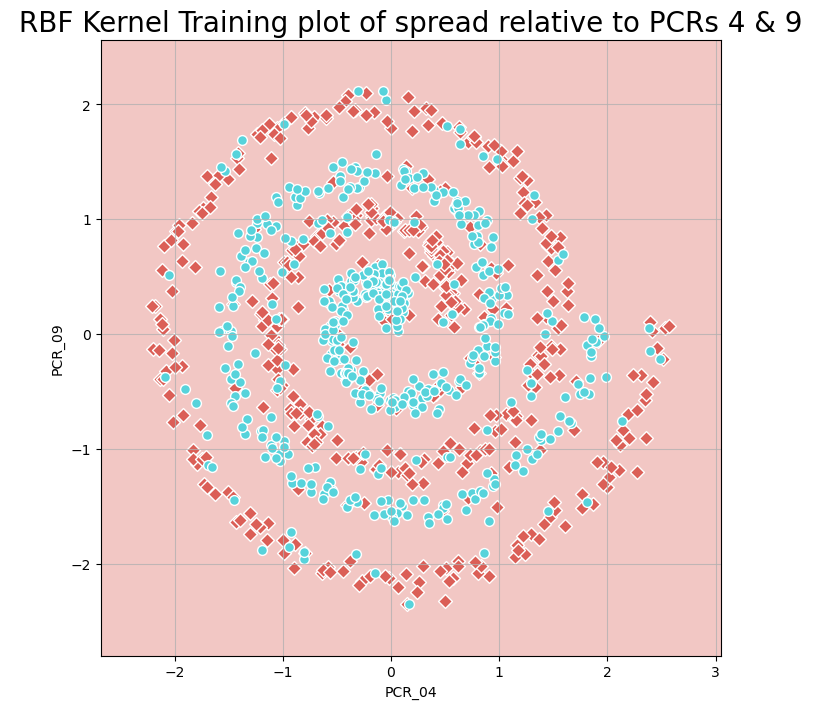

In [33]:
visualize_clf(clf = rbf_model,
              X = X_train_pcr49,
              Y = y_train_pcr49,
              title =" RBF Kernel Training plot of spread relative to PCRs 4 & 9 ",
              xlabel = "PCR_04",
              ylabel ="PCR_09")

In [34]:
# Calculate training and test accuracies
train_acc = rbf_model.score(X_train_pcr49, y_train_pcr49)
test_acc = rbf_model.score(X_test_pcr49, y_test_pcr49)

print(f"Training Accuracy: {train_acc}")
print(f"Test Accuracy: {test_acc}")

Training Accuracy: 0.501
Test Accuracy: 0.496


* Question 15

In [35]:
from sklearn.svm import SVC
# Hyper Params
C = 1
gamma = 200
# Train the SVM model
rbf_model = SVC(C=C, kernel='rbf', gamma=gamma)
rbf_model.fit(X_train_pcr49, y_train_pcr49)

SVC(C=1, gamma=200)

C:\Users\kingh\Desktop\Semester6\Intro-to-machine-learning\Intro-toMachine-Learning-Technion\env\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


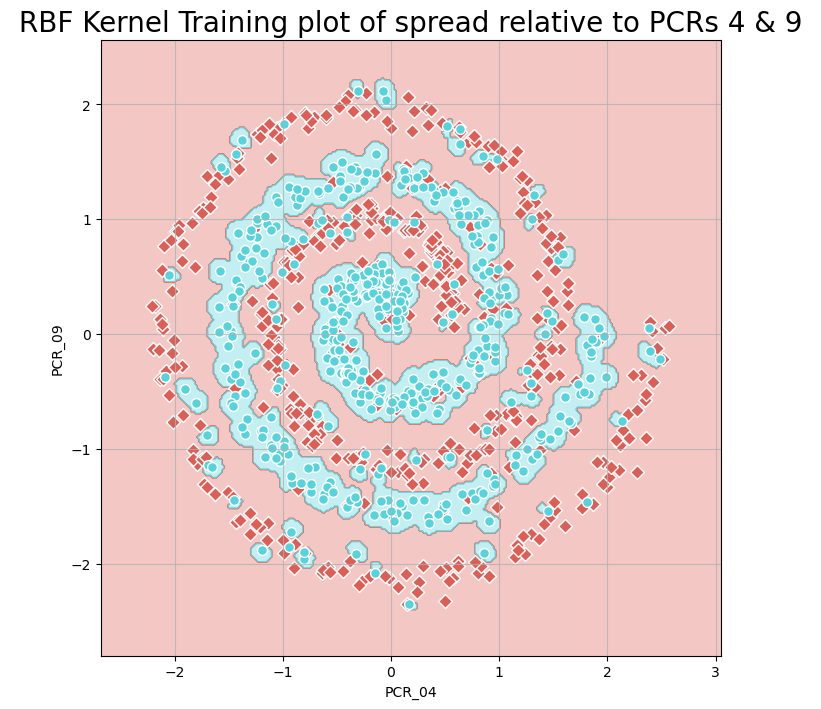

In [36]:
visualize_clf(clf = rbf_model,
              X = X_train_pcr49,
              Y = y_train_pcr49,
              title =" RBF Kernel Training plot of spread relative to PCRs 4 & 9 ",
              xlabel = "PCR_04",
              ylabel ="PCR_09")

In [37]:
# Calculate training and test accuracies
train_acc = rbf_model.score(X_train_pcr49, y_train_pcr49)
test_acc = rbf_model.score(X_test_pcr49, y_test_pcr49)

print(f"Training Accuracy: {train_acc}")
print(f"Test Accuracy: {test_acc}")

Training Accuracy: 0.921
Test Accuracy: 0.744


* Question 16

In [38]:
from sklearn.svm import SVC
# Hyper Params
C = 1
gamma = 5000
# Train the SVM model
rbf_model = SVC(C=C, kernel='rbf', gamma=gamma)
rbf_model.fit(X_train_pcr49, y_train_pcr49)

SVC(C=1, gamma=5000)

C:\Users\kingh\Desktop\Semester6\Intro-to-machine-learning\Intro-toMachine-Learning-Technion\env\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


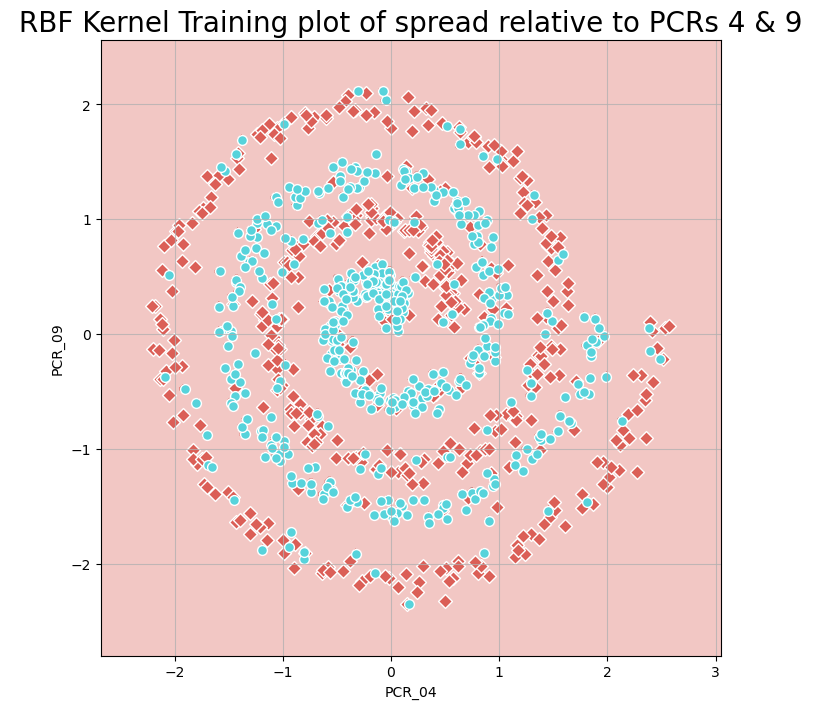

In [39]:
visualize_clf(clf = rbf_model,
              X = X_train_pcr49,
              Y = y_train_pcr49,
              title =" RBF Kernel Training plot of spread relative to PCRs 4 & 9 ",
              xlabel = "PCR_04",
              ylabel ="PCR_09")

In [40]:
# Calculate training and test accuracies
train_acc = rbf_model.score(X_train_pcr49, y_train_pcr49)
test_acc = rbf_model.score(X_test_pcr49, y_test_pcr49)

print(f"Training Accuracy: {train_acc}")
print(f"Test Accuracy: {test_acc}")

Training Accuracy: 0.999
Test Accuracy: 0.624
